In [6]:
%matplotlib inline
#
from multifunbrain import *
from multifunbrain.notebook import *
#
if Path.cwd().name != 'multifun-brain':
    path_root = Path.cwd().parent
    os.chdir(path_root)
#
path_data =  path_root / 'data'
path_fig = path_data / 'figures' /'more_figures'
path_ts = path_data / 'atlas_timecourses'
path_corrmat = path_data / 'correlation_matrices'
path_freq_contrast = path_corrmat / 'freq-contrast'
#

In [2]:
# Fetch the Schaefer 2018 atlas.
atlas = datasets.fetch_atlas_schaefer_2018(
    n_rois=100, data_dir=path_data
)
atlas_filename = atlas.maps
atlas_img = image.load_img(atlas_filename)
atlas_data = atlas_img.get_fdata()
#
rois = atlas.labels
rois_label_map = {i: ll for i, ll in enumerate(rois)}
roi_indices = np.unique(list(rois_label_map.keys()))
# Load MNI152 template for the background.
template = load_mni152_template()

[get_dataset_dir] Dataset found in /home/opisthofulax/Documents/UniPa/projects/multifun-brain/data/schaefer_2018
[fetch_single_file] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order.txt ...
[fetch_single_file]  ...done. (0 seconds, 0 min)

[fetch_single_file] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.nii.gz ...
[fetch_single_file]  ...done. (0 seconds, 0 min)



In [29]:
# Find all .pkl files in subfolders
files = list(path_freq_contrast.glob('**/*.pkl'))
file_names = [x.name for x in files]
labels_name = ['_'.join([ln[-3], ln[-2], ln[-1]]).replace('.ts.1D', '').replace('.pkl', '') for ln in [x.split('_') for x in file_names]]
files_dict = dict(zip(labels_name, files))

In [31]:
corr_matrices = {}
for label, file in files_dict.items():
    with open(file, 'rb') as f:
        matrix = pk.load(f)
    
    # Clean matrix: remove NaN and symmetrize
    matrix_no_nan = np.nan_to_num(matrix, nan=0.0)
    matrix_clean = (matrix_no_nan + matrix_no_nan.T) / 2
    
    # Marchenko-Pastur parameters
    n_channels, time_steps = matrix_clean.shape[0], 488  # Adjust time_steps if needed
    gamma = time_steps / n_channels
    lambda_min = (1 - np.sqrt(1/gamma))**2
    lambda_max = (1 + np.sqrt(1/gamma))**2
    
    # MP-based correlation matrix cleaning
    evals_orig, evecs_orig = np.linalg.eigh(matrix_clean)
    sort_idx = np.argsort(evals_orig)[::-1]
    evals_orig, evecs_orig = evals_orig[sort_idx], evecs_orig[:, sort_idx]
    
    # Identify signal vs noise eigenvectors based on MP bounds
    signal_mask = (evals_orig < lambda_min) | (evals_orig > lambda_max)
    n_signal, n_noise = np.sum(signal_mask), np.sum(~signal_mask)
    
    # Project onto signal subspace and convert back to correlation matrix
    signal_projector = evecs_orig[:, signal_mask] @ evecs_orig[:, signal_mask].T
    matrix_signal_proj = signal_projector @ matrix_clean @ signal_projector
    
    # Normalize to correlation form (cov2corr transformation)
    diag_elements = np.diag(matrix_signal_proj).copy()
    diag_elements[diag_elements <= 0] = 1e-10
    D_inv = np.diag(1.0 / np.sqrt(diag_elements))
    matrix_mp_cleaned = D_inv @ matrix_signal_proj @ D_inv
    
    # Ensure valid correlation matrix
    matrix_mp_cleaned = (matrix_mp_cleaned + matrix_mp_cleaned.T) / 2
    np.fill_diagonal(matrix_mp_cleaned, 1.0)
    
    # Store cleaned matrix
    corr_matrices[label] = matrix_mp_cleaned
    
    print(f"{label}: Removed {n_noise-np.sum((np.linalg.eigvals(matrix_mp_cleaned) >= lambda_min) & (np.linalg.eigvals(matrix_mp_cleaned) <= lambda_max))} noise eigenvalues")

bold_s4_120s: Removed 4 noise eigenvalues
kwoptcomMIRDenoised_bold_sstar: Removed 32 noise eigenvalues
bold_s5_120s: Removed 1 noise eigenvalues
bold_sstar_120s: Removed 22 noise eigenvalues
kwoptcomMIRDenoised_bold_s4: Removed 27 noise eigenvalues
kwoptcomMIRDenoised_bold_s5: Removed 14 noise eigenvalues
17Networks_kwCBF4D_s4: Removed 18 noise eigenvalues
17Networks_kwCBF4D_sstar: Removed -3 noise eigenvalues
17Networks_kwCBF4D_s5: Removed 16 noise eigenvalues
kwfcurN_Vaso_sstar: Removed 29 noise eigenvalues
kwfcurN_Vaso_s5: Removed 22 noise eigenvalues
kwfcurN_Vaso_s4: Removed 32 noise eigenvalues
kwfurN_Bold_s4: Removed 33 noise eigenvalues
kwfurN_Bold_sstar: Removed 23 noise eigenvalues
kwfurN_Bold_s5: Removed 17 noise eigenvalues
Bold_sstar_120s: Removed 18 noise eigenvalues
Bold_s4_120s: Removed 9 noise eigenvalues
Bold_s5_120s: Removed 2 noise eigenvalues


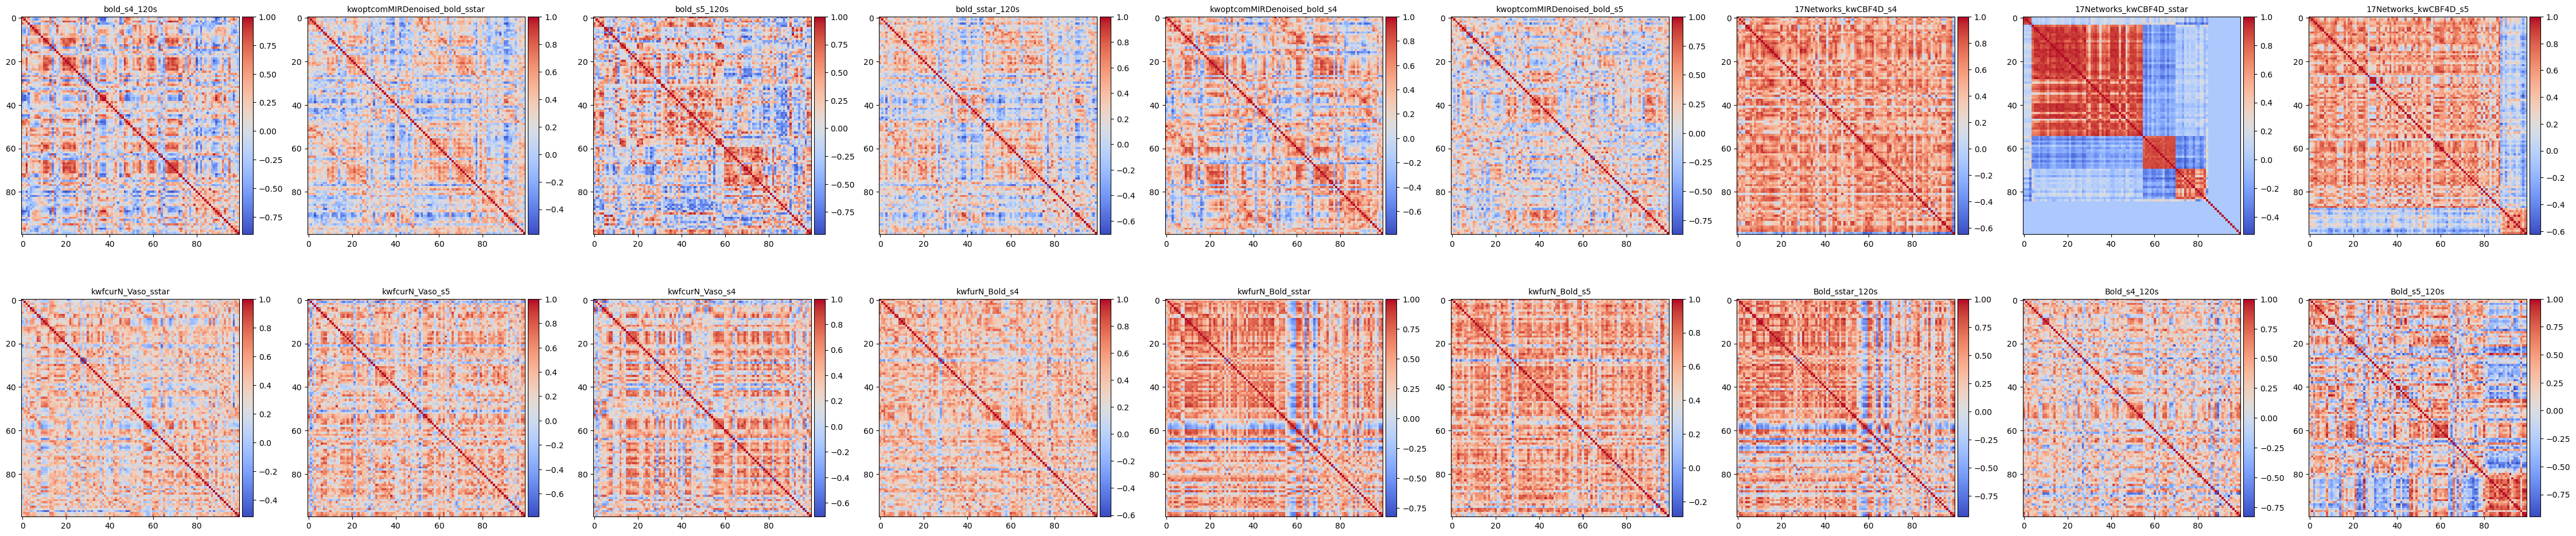

In [35]:
fig, ax = plt.subplots(2, len(labels_name)//2, figsize=(5*len(labels_name)//2, 10))
for i, fn in enumerate(labels_name):
    im = ax[i//(len(labels_name)//2), i%(len(labels_name)//2)].imshow(corr_matrices[fn], cmap='coolwarm')
    ax[i//(len(labels_name)//2), i%(len(labels_name)//2)].set_title(fn, fontsize=10)
    div, cax, clb = imshow_colorbar_caxdivider(im, ax[i//(len(labels_name)//2), i%(len(labels_name)//2)])
fig.tight_layout()

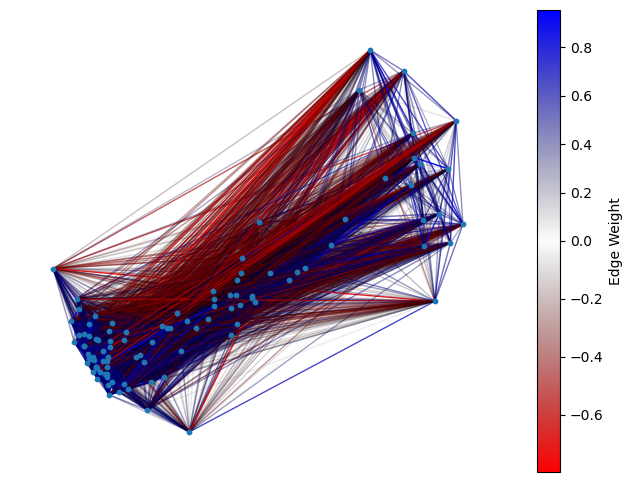

In [6]:
fn = labels_name[3]
G, lost_nodes_0 = get_giant_component_leftoff(nx.from_numpy_array(corr_matrices[fn]))
G = nx.convert_node_labels_to_integers(G)
#
L, spectrum = graph_laplacian_and_spectrum(G)
#
edge_weights = [G[u][v].get('weight', 0) for u, v in G.edges()]
norm = TwoSlopeNorm(vmin=min(edge_weights), vcenter=0, vmax=max(edge_weights))
cmap = LinearSegmentedColormap.from_list(
    'red_transparent_blue',
    [(0.0, (1, 0, 0, 1)),      # Red, opaque
     (0.5, (0, 0, 0, .01)),      # Transparent (white, alpha=0)
     (1.0, (0, 0, 1, 1))],     # Blue, opaque
    N=256
)
edge_colors = [cmap(norm(w)) for w in edge_weights]
#
fig, ax = plt.subplots(figsize=(8,6))
#
nx.draw(G, ax=ax, edge_color=edge_colors, node_size=10)
#
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(edge_weights)
#
plt.colorbar(sm, ax=ax, label='Edge Weight')
plt.show()

/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning: divide by zero encountered in log
  S[i] = -np.nansum(rho * np.log(rho)) / np.log(N)
/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning: invalid value encountered in multiply
  S[i] = -np.nansum(rho * np.log(rho)) / np.log(N)


is the graph connected: True


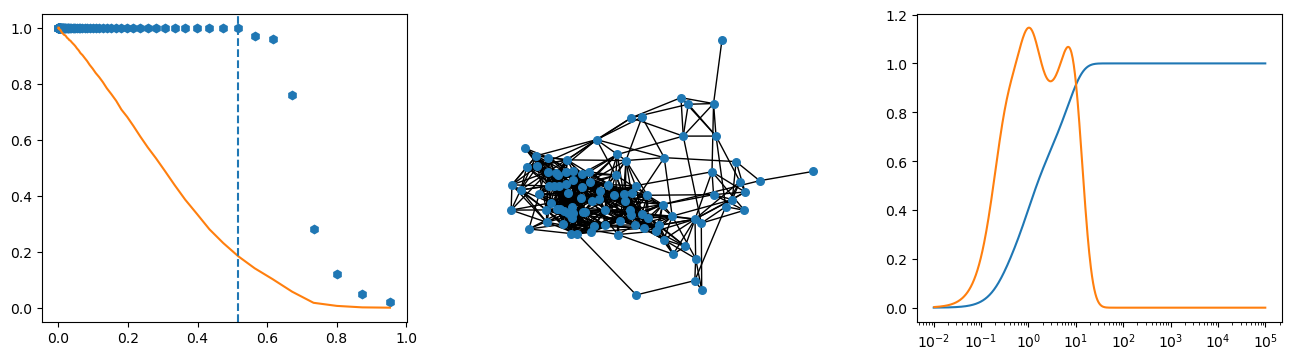

In [7]:
A_old = nx.to_numpy_array(G)
A_new = np.where(A_old < 0, 0, A_old)
G_pos = nx.from_numpy_array(A_new)
Th, Einf, Pinf = compute_threshold_stats_fast(G_pos)
Th, jump = find_threshold_jumps(G_pos)
#
sel_thresh = Th[jump[0]]
#
A_prime = nx.to_numpy_array(G_pos)
A_thresh = np.where(A_prime < sel_thresh, 0, A_prime)
G_pos, lost_nodes_1 = get_giant_component_leftoff(nx.from_numpy_array(A_thresh))
L_pos, spectrum = graph_laplacian_and_spectrum(G_pos)
Sm1, dS, VarL, tau  = entropy(spectrum)
#
fig, ax = plt.subplots(ncols=3, figsize=(16,4))
#
pos = nx.spring_layout(G_pos, k=0.15)
nx.draw(G_pos, ax=ax[1], node_size=30)
#
ax[2].plot(tau, Sm1)
ax[2].plot(tau[1:], dS)
ax[2].set_xscale('log')

ax[0].plot(Th, Pinf, 'h')
ax[0].plot(Th, Einf)
ax[0].axvline(sel_thresh, ls='--')
print("is the graph connected:", nx.is_connected(G_pos))

In [8]:
tau = 1/max(spectrum)
rho_m = lambda tau: rho_matrix(tau, L_pos)
dists = symmetrized_inverse_distance(tau, rho_m)
linkage_matrix, label_list, tmax = compute_normalized_linkage(dists, G_pos, method='ward')
tmin = linkage_matrix[::, 2][0] - 0.5*linkage_matrix[::, 2][0]
threshold, *_ = compute_optimal_threshold(linkage_matrix)
optimal_clusters = fcluster(linkage_matrix, t=threshold, criterion='distance')

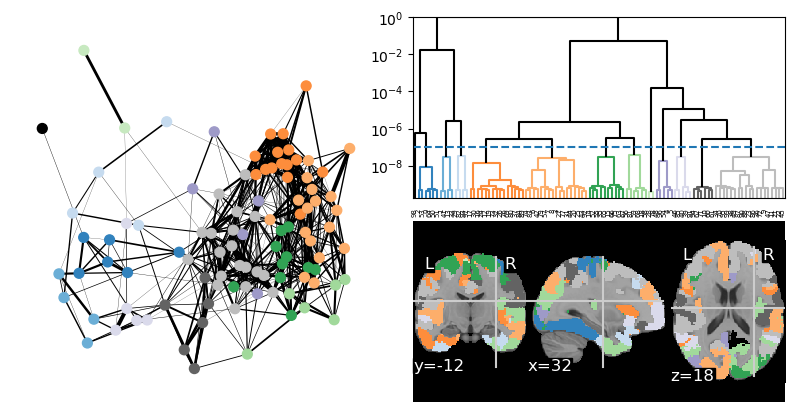

In [9]:
from matplotlib import gridspec
from scipy.cluster.hierarchy import set_link_color_palette

fig = plt.figure(figsize=(10, 5))
gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.3, wspace=0.3)

threshold = 1e-7
optimal_clusters2 = fcluster(linkage_matrix, t=threshold, criterion='distance')

# Generate a larger color palette to avoid repetition
n_colors = max(optimal_clusters2)  # Increase this if you need more unique colors
colors = plt.cm.tab20c(np.linspace(0, 1, n_colors))
colors = [plt.matplotlib.colors.rgb2hex(c) for c in colors]
# Optionally use other colormaps: tab20, tab20b, tab20c, hsv, rainbow, etc.
# Or combine multiple colormaps for even more colors
set_link_color_palette(colors)

ax_dendro = fig.add_subplot(gs[0:2, 3:6])
dendro = dendrogram(
    linkage_matrix,
    ax=ax_dendro,
    color_threshold=threshold,
    above_threshold_color='k',
    orientation='top',
    labels=label_list
)
ax_dendro.set_yscale('log')
ax_dendro.axhline(threshold, ls='--')
ax_dendro.set_ylim(tmin, 1)
#
ax_graph = fig.add_subplot(gs[0:4, 0:3])
leaf_label_colors = {label: color for label, color in zip(dendro['ivl'], dendro['leaves_color_list'])}
node_colors = [leaf_label_colors[label] for _,label in enumerate(label_list)]
edge_weights = [G_pos[u][v].get('weight', 0) for u, v in G_pos.edges()]
min_w, max_w = min(edge_weights), max(edge_weights)
widths = [0.1 + (abs(w) - abs(min_w)) / (abs(max_w) - abs(min_w)) * (3 - 0.1) if max_w != min_w else 3 for w in edge_weights]
pos = nx.spring_layout(G_pos, seed=42, k=0.15)  # positions for all nodes
#
nx.draw(G_pos, pos=pos, ax=ax_graph, width=widths, node_size=50, node_color=node_colors)
#
ax_nilearn = fig.add_subplot(gs[2:4, 3:6])
#
indices_to_insert = sorted(lost_nodes_0 + lost_nodes_1)
node_colors_all = node_colors.copy()
for idx in reversed(indices_to_insert):
    node_colors_all.insert(idx, 'white')
cmap = ListedColormap(node_colors_all)
#
plotting.plot_stat_map(atlas_img, bg_img=template, axes=ax_nilearn, cmap=cmap, colorbar=False)
# plotting.show()

In [10]:
import plotly.graph_objects as go

# Generate 5 logarithmically spaced threshold values
thresholds = np.logspace(np.log10(tmin), np.log10(1e-5), 5)

# Get cluster assignments for each threshold
cluster_assignments = {}
for i, thresh in enumerate(thresholds):
    clusters = fcluster(linkage_matrix, t=thresh, criterion='distance')
    cluster_assignments[i] = clusters

# Generate consistent colors for each cluster at each level
cluster_colors_dict = {}
for level in range(len(thresholds)):
    unique_clusters = np.unique(cluster_assignments[level])
    n_clusters = len(unique_clusters)
    # Generate colors for this level
    colors_level = plt.cm.tab20(np.linspace(0, 1, n_clusters))
    # Store colors for each cluster at this level
    cluster_colors_dict[level] = {}
    for idx, cluster in enumerate(unique_clusters):
        cluster_colors_dict[level][cluster] = plt.matplotlib.colors.rgb2hex(colors_level[idx])

# Build Sankey diagram data
sources = []
targets = []
values = []
labels = []
node_colors = []

# Create labels for each level and assign colors
for level in range(len(thresholds)):
    unique_clusters = np.unique(cluster_assignments[level])
    for cluster in unique_clusters:
        labels.append(f"L{level}_C{cluster}")
        node_colors.append(cluster_colors_dict[level][cluster])

# Create flows between consecutive levels
offset = 0
for level in range(len(thresholds) - 1):
    current_clusters = cluster_assignments[level]
    next_clusters = cluster_assignments[level + 1]
    
    # Count unique clusters at current and next level
    n_current = len(np.unique(current_clusters))
    n_next = len(np.unique(next_clusters))
    
    # Create transition matrix
    for node_idx in range(len(current_clusters)):
        curr_cluster = current_clusters[node_idx]
        next_cluster = next_clusters[node_idx]
        
        # Find indices in label list
        source_idx = labels.index(f"L{level}_C{curr_cluster}")
        target_idx = labels.index(f"L{level+1}_C{next_cluster}")
        
        # Check if this flow already exists
        try:
            flow_idx = sources.index(source_idx)
            if targets[flow_idx] == target_idx:
                values[flow_idx] += 1
                continue
        except ValueError:
            pass
        
        # Add new flow
        sources.append(source_idx)
        targets.append(target_idx)
        values.append(1)

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
    )
)])

fig.update_layout(
    title=f"Node Clustering Flow Across {len(thresholds)} Threshold Levels",
    font_size=10,
    height=600,
    width=1200
)

fig.show()

print(f"Thresholds: {thresholds}")
print(f"Number of clusters at each level: {[len(np.unique(cluster_assignments[i])) for i in range(len(thresholds))]}")

Thresholds: [1.93434806e-10 2.91676182e-09 4.39812240e-08 6.63183413e-07
 1.00000000e-05]
Number of clusters at each level: [100, 28, 13, 9, 6]


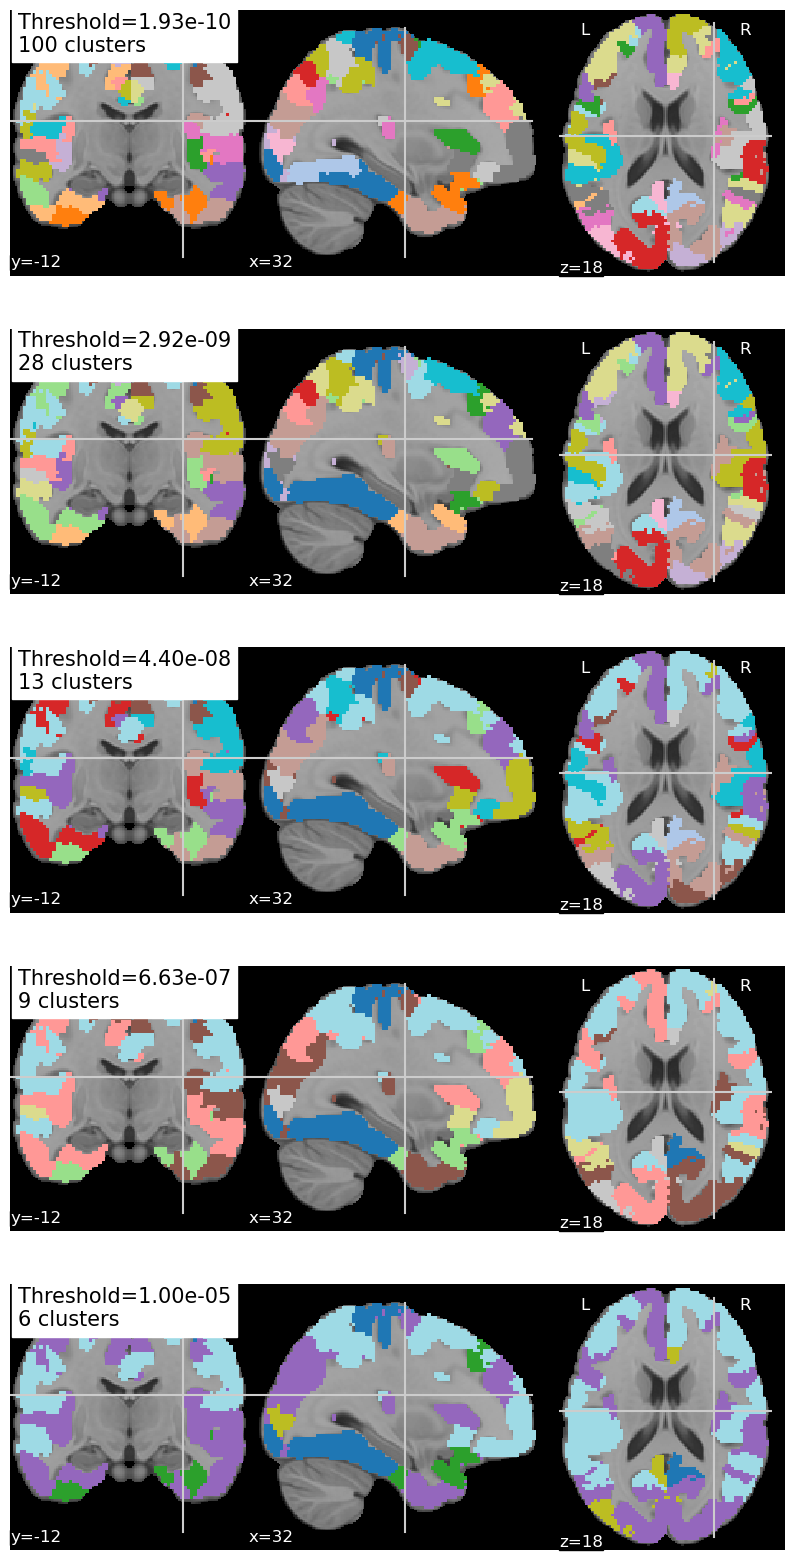

In [11]:
# Plot brain partitions for each threshold level
n_thresholds = len(thresholds)
fig, axes = plt.subplots(n_thresholds, 1, figsize=(10, 4*n_thresholds))

# Ensure axes is iterable even if there's only one subplot
if n_thresholds == 1:
    axes = [axes]

for i, thresh in enumerate(thresholds):
    # Get cluster assignments for this threshold
    clusters = cluster_assignments[i]
    
    # Map each node to its cluster color using the same colors as Sankey
    node_colors_level = []
    for node_cluster in clusters:
        node_colors_level.append(cluster_colors_dict[i][node_cluster])
    
    # Insert white color for lost nodes
    indices_to_insert = sorted(lost_nodes_0 + lost_nodes_1)
    node_colors_all_level = node_colors_level.copy()
    for idx in reversed(indices_to_insert):
        node_colors_all_level.insert(idx, 'white')
    
    # Create colormap from node colors
    cmap_level = ListedColormap(node_colors_all_level)
    
    # Plot brain partition
    n_clusters = len(np.unique(clusters))
    plotting.plot_stat_map(
        atlas_img, 
        bg_img=template, 
        axes=axes[i], 
        cmap=cmap_level, 
        colorbar=False,
        title=f'Threshold={thresh:.2e}\n{n_clusters} clusters'
    )

plt.show()

# Methodology: Graph-Theoretic Analysis of Brain Functional Connectivity

## Overview

This notebook implements a comprehensive pipeline for analyzing brain functional connectivity networks derived from fMRI time series data. The analysis combines spectral filtering, random matrix theory, graph theory, percolation analysis, and hierarchical clustering to identify and characterize functional brain modules across multiple scales.

---

## 1. Data and Atlas

### Brain Parcellation
We use the **Schaefer 2018 atlas** with 400 ROIs and 7 Yeo networks at 2mm resolution. This parcellation provides a fine-grained functional subdivision of the cerebral cortex based on resting-state fMRI connectivity patterns.

**Atlas specifications:**
- Parcels: 400 cortical regions
- Resolution: 2mm MNI152 space
- Network organization: 7 Yeo networks (Visual, Somatomotor, Dorsal Attention, Ventral Attention, Limbic, Frontoparietal, Default)

---

## 2. Correlation Matrix Cleaning: Marchenko-Pastur Theory

### Theoretical Background

Brain correlation matrices contain both **signal** (true functional connectivity) and **noise** (measurement error, physiological artifacts). Random Matrix Theory (RMT), specifically the Marchenko-Pastur (MP) distribution, provides a principled way to separate these components.

For a $N \times T$ data matrix ($N$ channels, $T$ time points), the **null hypothesis** is that observations are uncorrelated. Under this hypothesis, the eigenvalue spectrum of the correlation matrix follows the Marchenko-Pastur distribution:

$$
\rho_{MP}(\lambda) = \frac{\gamma}{2\pi\sigma^2} \frac{\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}}{\lambda}
$$

where:
- $\gamma = T/N$ is the aspect ratio
- $\lambda_{\pm} = \sigma^2(1 \pm \sqrt{1/\gamma})^2$ are the theoretical bounds
- Eigenvalues within $[\lambda_-, \lambda_+]$ correspond to **noise**
- Eigenvalues outside this range correspond to **signal**

### Implementation

**Step 1: Compute MP bounds**
```python
gamma = time_steps / n_channels
lambda_min = (1 - sqrt(1/gamma))^2
lambda_max = (1 + sqrt(1/gamma))^2
```

**Step 2: Eigendecomposition**

Decompose the correlation matrix $C$ into eigenvalues and eigenvectors:
$$
C = \sum_{i=1}^N \lambda_i \mathbf{v}_i \mathbf{v}_i^T
$$

**Step 3: Signal projection**

Identify signal eigenvectors ($\lambda_i < \lambda_{min}$ or $\lambda_i > \lambda_{max}$) and project:
$$
C_{signal} = \sum_{i \in \text{signal}} \lambda_i \mathbf{v}_i \mathbf{v}_i^T
$$

**Step 4: Renormalization**

Convert back to correlation form (diagonal = 1):
$$
C_{cleaned}^{ij} = \frac{C_{signal}^{ij}}{\sqrt{C_{signal}^{ii} C_{signal}^{jj}}}
$$

This procedure removes noise components while preserving genuine functional connectivity patterns.

---

## 3. Graph Construction and Preprocessing

### Network Representation

From the cleaned correlation matrix $C_{cleaned}$, we construct a weighted graph $G = (V, E, W)$ where:
- **Nodes** $V$: brain regions (ROIs)
- **Edges** $E$: functional connections
- **Weights** $W$: correlation values $C_{cleaned}^{ij}$

### Giant Component Extraction

We extract the **giant connected component** to ensure graph connectivity for subsequent analyses. Disconnected nodes are tracked as `lost_nodes_0`.

### Sign Processing

For positive-weight graph algorithms, we convert to absolute values:
$$
A_{pos} = |A|
$$

---

## 4. Percolation-Based Thresholding

### Motivation

Weak correlations may reflect noise or indirect connections. We use **percolation theory** to identify an optimal threshold that preserves the network's structural integrity while removing spurious connections.

### Percolation Metrics

For each threshold $\theta$, we compute:

1. **Giant component size** $P_\infty(\theta)$: fraction of nodes in the largest connected component
2. **Global efficiency** $E_{glob}(\theta)$: average inverse shortest path length

$$
E_{glob} = \frac{1}{N(N-1)} \sum_{i \neq j} \frac{1}{d_{ij}}
$$

### Threshold Selection

We identify **discontinuities** (jumps) in $P_\infty(\theta)$ or $E_{glob}(\theta)$ using numerical derivatives. The first major jump corresponds to the **percolation transition**, where weak edges are pruned while maintaining network cohesion.

**Thresholded adjacency matrix:**
$$
A_{thresh}^{ij} = \begin{cases} 
A_{pos}^{ij} & \text{if } A_{pos}^{ij} \geq \theta \\
0 & \text{otherwise}
\end{cases}
$$

---

## 5. Graph Spectral Analysis

### Graph Laplacian

The **normalized graph Laplacian** encodes network topology:

$$
\mathcal{L} = D - A
$$

where $D$ is the degree matrix and $A$ is the adjacency matrix.

The eigenspectrum $\{\lambda_0, \lambda_1, \ldots, \lambda_{N-1}\}$ (with $0 = \lambda_0 \leq \lambda_1 \leq \cdots$) characterizes:
- **Connectivity**: $\lambda_1 > 0$ iff the graph is connected (algebraic connectivity)
- **Modularity**: eigenvalue gaps indicate community structure
- **Diffusion dynamics**: governs heat/information spreading on the network

### Von Neumann Entropy

We compute the **von Neumann entropy** as a function of temperature $\tau$:

$$
S(\tau) = -\sum_{i=1}^{N-1} \rho_i(\tau) \ln \rho_i(\tau)
$$

where the density matrix is:
$$
\rho_i(\tau) = \frac{e^{-\tau \lambda_i}}{Z(\tau)}, \quad Z(\tau) = \sum_{j=1}^{N-1} e^{-\tau \lambda_j}
$$

**Specific heat** (sensitivity to temperature changes):
$$
C(\tau) = \frac{dS}{d\tau}
$$

Peaks in $C(\tau)$ reveal characteristic scales of network organization.

---

## 6. Diffusion-Based Hierarchical Clustering

### Diffusion Distance

At temperature $\tau$, the **diffusion distance** between nodes $i$ and $j$ quantifies how similarly they are influenced by network diffusion:

$$
d_\tau(i, j) = \|\rho_i(\tau) - \rho_j(\tau)\|
$$

where $\rho_i(\tau)$ is the $i$-th row of the thermal density matrix.

We **symmetrize** the distance matrix:
$$
D_{sym}^{ij} = \frac{d_\tau(i,j) + d_\tau(j,i)}{2}
$$

### Hierarchical Clustering

Using the diffusion distance matrix, we perform **Ward's hierarchical clustering**:

1. **Initialize**: each node is a singleton cluster
2. **Merge**: iteratively merge clusters that minimize within-cluster variance
3. **Record**: construct a dendrogram encoding the merge hierarchy

**Linkage matrix** $L$ stores:
- Cluster IDs being merged
- Merge distance
- Number of nodes in new cluster

### Optimal Partition

We identify the optimal clustering threshold using **silhouette scores** or **dendrogram gap statistics**, balancing:
- **Homogeneity**: nodes within clusters are tightly connected
- **Separation**: nodes across clusters are weakly connected

---

## 7. Multi-Scale Brain Parcellation

### Hierarchical Threshold Sweep

To reveal multi-scale organization, we compute partitions at multiple thresholds:

$$
\{\tau_1, \tau_2, \ldots, \tau_K\} \text{ logarithmically spaced from } \tau_{min} \text{ to } \tau_{max}
$$

where:
- $\tau_{min}$: threshold giving maximal fragmentation (each node is a cluster)
- $\tau_{max}$: threshold giving 2 clusters (hemispheric division)

### Sankey Flow Diagram

We track how **nodes transition between clusters** across threshold levels using a Sankey diagram:
- **Nodes**: clusters at each threshold level
- **Links**: node flows from level $k$ to level $k+1$
- **Width**: number of nodes in each flow

This visualization reveals:
- **Hierarchical merging**: how fine-scale modules aggregate into macro-scale networks
- **Stable cores**: clusters that persist across scales
- **Flexible associations**: regions that switch affiliations

---

## 8. Anatomical Projection

### Brain Visualization

Using **Nilearn**, we project cluster assignments onto the Schaefer atlas in MNI152 space:

1. Map node colors from dendrogram to atlas ROIs
2. Handle disconnected regions (lost nodes) by assigning white color
3. Create discrete colormap: `ListedColormap(node_colors)`
4. Overlay on MNI152 template using `plot_stat_map`

This enables:
- **Spatial interpretation**: identifying functional modules in anatomical context
- **Network comparison**: visualizing differences across conditions/scales
- **Publication-ready figures**: high-resolution brain renderings

---

## 9. Computational Pipeline Summary

### For each correlation matrix:

1. **Load and clean** using Marchenko-Pastur filtering
2. **Build graph** and extract giant component
3. **Apply percolation threshold** to prune weak edges
4. **Compute Laplacian spectrum** and entropy measures
5. **Perform diffusion clustering** at optimal temperature
6. **Generate multi-scale partitions** across threshold range
7. **Visualize results**:
   - Correlation matrix heatmap
   - Network topology
   - Percolation curves
   - Entropy/specific heat
   - Dendrogram
   - Brain projections
   - Sankey flow diagram

### Output Files (per matrix):

- `{name}_01_correlation_matrix_and_network.pdf`: Raw connectivity
- `{name}_02_thresholding_network_entropy.pdf`: Graph preprocessing
- `{name}_03_clustering_network_dendro_brain.pdf`: Primary partition
- `{name}_04_sankey_diagram.html`: Multi-scale hierarchy (interactive)
- `{name}_05_multithreshold_brain_partitions.pdf`: Scale-dependent modules

---

## Key Advantages

✓ **Noise suppression**: Marchenko-Pastur filtering removes spurious correlations  
✓ **Data-driven thresholding**: Percolation theory avoids arbitrary cutoffs  
✓ **Multi-scale detection**: Hierarchical clustering reveals nested organization  
✓ **Diffusion-based similarity**: Captures indirect connectivity patterns  
✓ **Anatomical grounding**: Results projected onto standard brain atlas  
✓ **Reproducible**: Fully automated pipeline from correlation matrix to figures

---

## References

- **Random Matrix Theory**: Marčenko & Pastur (1967), *Math. USSR Sbornik*
- **Percolation on Graphs**: Newman & Ziff (2000), *Phys. Rev. E*
- **Graph Laplacian Entropy**: Passerini & Severini (2009), *J. Complex Networks*
- **Diffusion Maps**: Coifman & Lafon (2006), *Appl. Comput. Harmon. Anal.*
- **Schaefer Atlas**: Schaefer et al. (2018), *Cereb. Cortex*

In [13]:
# Comprehensive analysis for each correlation matrix
for fn in labels_name:
    print(f"\n{'='*60}")
    print(f"Processing: {fn}")
    print(f"{'='*60}")
    
    # ========== 1. CORRELATION MATRIX AND INITIAL NETWORK ==========
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot correlation matrix
    im = ax1.imshow(corr_matrices[fn], cmap='coolwarm', vmin=-1, vmax=1)
    ax1.set_title(f'Correlation Matrix: {fn}', fontsize=12)
    plt.colorbar(im, ax=ax1, shrink=0.8)
    
    # Plot initial network
    G_init, _ = get_giant_component_leftoff(nx.from_numpy_array(corr_matrices[fn]))
    G_init = nx.convert_node_labels_to_integers(G_init)
    edge_weights_init = [G_init[u][v].get('weight', 0) for u, v in G_init.edges()]
    norm_init = TwoSlopeNorm(vmin=min(edge_weights_init), vcenter=0, vmax=max(edge_weights_init))
    cmap_init = LinearSegmentedColormap.from_list(
        'red_transparent_blue',
        [(0.0, (1, 0, 0, 1)), (0.5, (0, 0, 0, .01)), (1.0, (0, 0, 1, 1))], N=256
    )
    edge_colors_init = [cmap_init(norm_init(w)) for w in edge_weights_init]
    nx.draw(G_init, ax=ax2, edge_color=edge_colors_init, node_size=10)
    sm_init = plt.cm.ScalarMappable(cmap=cmap_init, norm=norm_init)
    sm_init.set_array(edge_weights_init)
    plt.colorbar(sm_init, ax=ax2, label='Edge Weight', shrink=0.8)
    ax2.set_title('Initial Network (no threshold)', fontsize=12)
    
    plt.tight_layout()
    plt.savefig(path_fig / f'{fn}_01_correlation_matrix_and_network.pdf', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ========== 2. THRESHOLDING PROCEDURE ==========
    G, lost_nodes_0 = get_giant_component_leftoff(nx.from_numpy_array(corr_matrices[fn]))
    G = nx.convert_node_labels_to_integers(G)
    
    A_old = nx.to_numpy_array(G)
    A_new = np.where(A_old < 0, 0, A_old)
    G_pos = nx.from_numpy_array(A_new)
    Th, Einf, Pinf = compute_threshold_stats_fast(G_pos)
    Th, jump = find_threshold_jumps(G_pos)
    
    sel_thresh = Th[jump[0]] if len(jump) > 0 else Th[len(Th)//2]
    
    A_prime = nx.to_numpy_array(G_pos)
    A_thresh = np.where(A_prime < sel_thresh, 0, A_prime)
    G_pos, lost_nodes_1 = get_giant_component_leftoff(nx.from_numpy_array(A_thresh))
    L_pos, spectrum = graph_laplacian_and_spectrum(G_pos)
    Sm1, dS, VarL, tau = entropy(spectrum)
    
    fig, ax = plt.subplots(ncols=3, figsize=(16, 4))
    
    # Thresholding plot
    ax[0].plot(Th, Pinf, 'h', label='P∞')
    ax[0].plot(Th, Einf, label='E∞')
    ax[0].axvline(sel_thresh, ls='--', color='red', label=f'Selected={sel_thresh:.3f}')
    ax[0].set_xlabel('Threshold')
    ax[0].set_ylabel('Percolation/Efficiency')
    ax[0].set_title('Threshold Selection')
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)
    
    # Thresholded network
    pos_net = nx.spring_layout(G_pos, k=0.15, seed=42)
    nx.draw(G_pos, pos=pos_net, ax=ax[1], node_size=30)
    ax[1].set_title(f'Thresholded Network ({len(G_pos.nodes())} nodes)')
    
    # Entropy and specific heat
    ax[2].plot(tau, Sm1, label='Entropy S(τ)')
    ax[2].plot(tau[1:], dS, label='Specific Heat dS/dτ')
    ax[2].set_xscale('log')
    ax[2].set_xlabel('Temperature τ')
    ax[2].set_ylabel('S / dS')
    ax[2].set_title('Entropy Analysis')
    ax[2].legend()
    ax[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(path_fig / f'{fn}_02_thresholding_network_entropy.pdf', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ========== 3. CLUSTERING: NETWORK, DENDROGRAM, BRAIN ==========
    tau_opt = 1/max(spectrum)
    rho_m = lambda tau: rho_matrix(tau, L_pos)
    dists = symmetrized_inverse_distance(tau_opt, rho_m)
    linkage_matrix, label_list, tmax = compute_normalized_linkage(dists, G_pos, method='ward')
    tmin = linkage_matrix[::, 2][0] - 0.5*linkage_matrix[::, 2][0]
    threshold_opt, *_ = compute_optimal_threshold(linkage_matrix, scaling_factor=0.95)
    
    # Use a reasonable threshold for visualization
    threshold_viz = max(threshold_opt, 1e-7)
    optimal_clusters = fcluster(linkage_matrix, t=threshold_viz, criterion='distance')
    
    # Set color palette
    n_colors = max(optimal_clusters)
    colors = plt.cm.tab20c(np.linspace(0, 1, n_colors))
    colors = [plt.matplotlib.colors.rgb2hex(c) for c in colors]
    set_link_color_palette(colors)
    
    fig = plt.figure(figsize=(14, 6))
    gs = gridspec.GridSpec(4, 6, figure=fig, hspace=0.3, wspace=0.3)
    
    # Dendrogram
    ax_dendro = fig.add_subplot(gs[0:2, 3:6])
    dendro = dendrogram(linkage_matrix, ax=ax_dendro, color_threshold=threshold_viz,
                        above_threshold_color='k', orientation='top', labels=label_list)
    ax_dendro.set_yscale('log')
    ax_dendro.axhline(threshold_viz, ls='--', color='red')
    ax_dendro.set_ylim(tmin, 1)
    ax_dendro.set_title(f'Dendrogram (threshold={threshold_viz:.2e})')
    
    # Graph with cluster colors
    ax_graph = fig.add_subplot(gs[0:4, 0:3])
    leaf_label_colors = {label: color for label, color in zip(dendro['ivl'], dendro['leaves_color_list'])}
    node_colors = [leaf_label_colors[label] for _, label in enumerate(label_list)]
    edge_weights = [G_pos[u][v].get('weight', 0) for u, v in G_pos.edges()]
    min_w, max_w = min(edge_weights), max(edge_weights)
    widths = [0.1 + (abs(w) - abs(min_w)) / (abs(max_w) - abs(min_w)) * (3 - 0.1) if max_w != min_w else 3 for w in edge_weights]
    pos_clust = nx.spring_layout(G_pos, seed=42, k=0.15)
    nx.draw(G_pos, pos=pos_clust, ax=ax_graph, width=widths, node_size=50, node_color=node_colors)
    ax_graph.set_title(f'Clustered Network ({n_colors} clusters)')
    
    # Brain projection
    ax_nilearn = fig.add_subplot(gs[2:4, 3:6])
    indices_to_insert = sorted(lost_nodes_0 + lost_nodes_1)
    node_colors_all = node_colors.copy()
    for idx in reversed(indices_to_insert):
        node_colors_all.insert(idx, 'white')
    cmap_brain = ListedColormap(node_colors_all)
    plotting.plot_stat_map(atlas_img, bg_img=template, axes=ax_nilearn, cmap=cmap_brain, colorbar=False)
    ax_nilearn.set_title('Brain Partition')
    
    plt.savefig(path_fig / f'{fn}_03_clustering_network_dendro_brain.pdf', dpi=300, bbox_inches='tight')
    plt.close()
    
    # ========== 4. SANKEY DIAGRAM AND MULTI-THRESHOLD BRAIN VIEWS ==========
    # Find threshold range: from all separated to 2 clusters
    # All separated: use tmin, 2 clusters: find threshold that gives 2 clusters
    thresh_all_sep = tmin * 1.1
    thresh_2_clusters = None
    for t in np.logspace(np.log10(tmin), np.log10(1), 100):
        n_clust = len(np.unique(fcluster(linkage_matrix, t=t, criterion='distance')))
        if n_clust <= 2:
            thresh_2_clusters = t
            break
    
    if thresh_2_clusters is None:
        thresh_2_clusters = 1e-2
    
    # Generate 5 logarithmically spaced thresholds
    thresholds_sankey = np.logspace(np.log10(thresh_all_sep), np.log10(thresh_2_clusters), 5)
    
    # Get cluster assignments for each threshold
    cluster_assignments_sankey = {}
    for i, thresh in enumerate(thresholds_sankey):
        clusters = fcluster(linkage_matrix, t=thresh, criterion='distance')
        cluster_assignments_sankey[i] = clusters
    
    # Generate consistent colors
    cluster_colors_dict_sankey = {}
    for level in range(len(thresholds_sankey)):
        unique_clusters = np.unique(cluster_assignments_sankey[level])
        n_clusters = len(unique_clusters)
        colors_level = plt.cm.tab20(np.linspace(0, 1, n_clusters))
        cluster_colors_dict_sankey[level] = {}
        for idx, cluster in enumerate(unique_clusters):
            cluster_colors_dict_sankey[level][cluster] = plt.matplotlib.colors.rgb2hex(colors_level[idx])
    
    # Build Sankey diagram data
    sources, targets, values, labels_sankey, node_colors_sankey = [], [], [], [], []
    
    for level in range(len(thresholds_sankey)):
        unique_clusters = np.unique(cluster_assignments_sankey[level])
        for cluster in unique_clusters:
            labels_sankey.append(f"L{level}_C{cluster}")
            node_colors_sankey.append(cluster_colors_dict_sankey[level][cluster])
    
    for level in range(len(thresholds_sankey) - 1):
        current_clusters = cluster_assignments_sankey[level]
        next_clusters = cluster_assignments_sankey[level + 1]
        
        for node_idx in range(len(current_clusters)):
            curr_cluster = current_clusters[node_idx]
            next_cluster = next_clusters[node_idx]
            
            source_idx = labels_sankey.index(f"L{level}_C{curr_cluster}")
            target_idx = labels_sankey.index(f"L{level+1}_C{next_cluster}")
            
            try:
                flow_idx = sources.index(source_idx)
                if targets[flow_idx] == target_idx:
                    values[flow_idx] += 1
                    continue
            except ValueError:
                pass
            
            sources.append(source_idx)
            targets.append(target_idx)
            values.append(1)
    
    # Create Sankey diagram
    fig_sankey = go.Figure(data=[go.Sankey(
        node=dict(pad=15, thickness=20, line=dict(color="black", width=0.5),
                  label=labels_sankey, color=node_colors_sankey),
        link=dict(source=sources, target=targets, value=values)
    )])
    
    fig_sankey.update_layout(
        title=f"{fn}: Clustering Flow Across Thresholds",
        font_size=10, height=600, width=1200
    )
    
    # Save as interactive HTML (kaleido not available for PDF export)
    fig_sankey.write_html(path_fig / f'{fn}_04_sankey_diagram.html')
    
    # Plot brain partitions for each threshold
    n_thresh = len(thresholds_sankey)
    fig_brains, axes_brains = plt.subplots(n_thresh, 1, figsize=(10, 4*n_thresh))
    if n_thresh == 1:
        axes_brains = [axes_brains]
    
    for i, thresh in enumerate(thresholds_sankey):
        clusters = cluster_assignments_sankey[i]
        node_colors_level = [cluster_colors_dict_sankey[i][nc] for nc in clusters]
        
        indices_to_insert = sorted(lost_nodes_0 + lost_nodes_1)
        node_colors_all_level = node_colors_level.copy()
        for idx in reversed(indices_to_insert):
            node_colors_all_level.insert(idx, 'white')
        
        cmap_level = ListedColormap(node_colors_all_level)
        n_clusters = len(np.unique(clusters))
        
        plotting.plot_stat_map(atlas_img, bg_img=template, axes=axes_brains[i], 
                              cmap=cmap_level, colorbar=False,
                              title=f'Threshold={thresh:.2e}, {n_clusters} clusters')
    
    plt.savefig(path_fig / f'{fn}_05_multithreshold_brain_partitions.pdf', dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✓ Saved all figures for {fn}")
    print(f"  - Clusters at thresholds: {[len(np.unique(cluster_assignments_sankey[i])) for i in range(len(thresholds_sankey))]}")


Processing: S4_kwoptcomMIRDenoised_bold


/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning:

divide by zero encountered in log

/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning:

invalid value encountered in multiply



✓ Saved all figures for S4_kwoptcomMIRDenoised_bold
  - Clusters at thresholds: [100, 26, 8, 4, 2]

Processing: Sstar_kwfurN_Bold


/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning:

divide by zero encountered in log

/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning:

invalid value encountered in multiply



✓ Saved all figures for Sstar_kwfurN_Bold
  - Clusters at thresholds: [100, 14, 6, 4, 2]

Processing: Sstar_kwoptcomMIRDenoised_bold


...

✓ Saved all figures for S4_kwfurN_Bold
  - Clusters at thresholds: [100, 20, 6, 4, 2]

Processing: S5_kwoptcomMIRDenoised_bold


/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning:

divide by zero encountered in log

/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning:

invalid value encountered in multiply



✓ Saved all figures for S5_kwoptcomMIRDenoised_bold
  - Clusters at thresholds: [100, 18, 8, 4, 2]

Processing: S5_kwfurN_Bold


/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning:

divide by zero encountered in log

/home/opisthofulax/Documents/UniPa/projects/multifun-brain/multifunbrain/analysis/lrglib.py:90: RuntimeWarning:

invalid value encountered in multiply



✓ Saved all figures for S5_kwfurN_Bold
  - Clusters at thresholds: [100, 25, 10, 4, 2]
